In [24]:
# =========================
# STANDARD LIBRARY
# =========================
import ast
from datetime import datetime

# =========================
# ENVIRONMENT & UTILITIES
# =========================
from google.colab import drive
from tqdm import tqdm

# =========================
# DATA & NUMERICAL
# =========================
import numpy as np
import pandas as pd

# =========================
# MACHINE LEARNING
# =========================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    log_loss
)

# =========================
# DEEP LEARNING & NLP
# =========================
import torch
from transformers import AutoModel, AutoTokenizer

import torch
from torch import nn
from transformers import AutoModel
from transformers.modeling_outputs import SequenceClassifierOutput

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np


# Read Cleaned Data
Data extracted and went through the data cleaning file. Look at Data_Clean.ipynb for the process.

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define the path based on your script
file_path = '/content/drive/MyDrive/BT4222 Project/Data/Court_Cases.csv'

try:
    # Load the CSV
    # Added encoding='utf-8-sig' to handle potential special characters in legal text
    df = pd.read_csv(file_path, encoding='utf-8-sig')

    print(f"Successfully loaded {len(df)} rows.")

    # Display first few rows to verify headers
    display(df.head())

except Exception as e:
    print(f"Error loading CSV: {e}")

Successfully loaded 358 rows.


,Case_Number,Coram,Judge,Date,Tribunal_Court,Plaintiff_Name,Defendant_Name,Combined_Facts,Issue,Rule,Application,Plaintiff_Label,Defendant_Label
0,CA 206/1999 (Counterclaim),Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-03,Court of Appeal,Gan Boon Hock,Kea Resources Pte Ltd,"[{'Fact_Type': 'CONTRACT_EVENT', 'Fact_Date': ...",Whether an employee is entitled to claim unpai...,An employee may claim financial entitlements i...,He was owed financial entitlements as per his ...,Claim Allowed,Liable
1,CA 206/1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-03,Court of Appeal,Kea Holdings Pte Ltd,Gan Boon Hock,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a director can be held legally respons...,A director must act in the best interests of t...,Gan diverted business and misrepresented sale ...,Claim Allowed In-part,Liable
2,Civil Appeal No 124 of 1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-28,Court of Appeal,Kumagai Property Marketing Pte Ltd,Low Hua Kin,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a subsidiary company can hold its dire...,A director is legally responsible for losses i...,The Plaintiff stated that it was used as a mer...,Claim Allowed,Liable
3,Civil Appeal No 124 of 1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-28,Court of Appeal,Kumagai-Zenecon Construction Pte Ltd (in liqui...,Low Hua Kin,"[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '198...",Whether a joint venture company can recover lo...,A director’s duty to the parent company extend...,The Plaintiff stated that the director’s unaut...,Claim Allowed,Liable
4,Suit 1032/1999,Kan Ting Chiu J,Kan Ting Chiu,2000-08-26,High Court of Singapore,Jurong Readymix Concrete Pte Ltd,Chng Heng Tiu,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a corporate guarantor is liable for un...,A guarantee is enforceable if supported by val...,A concrete supplier increased a contractor's c...,Claim Allowed,Liable


# Define Label
Using the defendant's labels as the main target variable.

In [4]:
label_mapping = {
    "Not Liable": 0,
    "Liable": 1
}

In [5]:
# Create the target integer column on the entire dataset
df['target'] = df['Defendant_Label'].map(label_mapping)

# Drop any rows where the label couldn't be mapped (NaNs)
df = df.dropna(subset=['target']).reset_index(drop=True)
df['target'] = df['target'].astype(int)

# Data Preparation

## Early Fusion
Early fusion of the text data of Facts, Issue, Rule.

`safe_eval` (The Data Rescuer): When you save lists or dictionaries (like your `Combined_Facts`) to a CSV, pandas often reads them back in as literal strings (e.g., "['fact 1', 'fact 2']"). safe_eval uses Python's ast.literal_eval to safely convert those strings back into actual Python lists and dictionaries without the security risks of the standard `eval()` function.

`build_bert_input`: This function takes the newly parsed Python objects and stitches them into a single, highly structured string. It explicitly labels the ISSUE:, the RULE:, and chronological FACTS:, separating the major logical blocks with the [SEP] token (which BERT uses to understand distinct segments of text).

In [6]:
# 1. Safe Evaluator (Handles the transition from CSV to Python objects)
def safe_eval(val):
    """Safely converts stringified lists/dicts to Python objects, handling NaNs."""
    if pd.isna(val):
        return []
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            return parsed
        except (ValueError, SyntaxError):
            return val
    return val

# 2. The Updated BERT Builder
def build_bert_input(row):
    text_blocks = []

    # Add Metadata directly into the text
    court = row.get('Tribunal_Court', 'Unknown Court')
    judge = row.get('Judge', 'Unknown Judge')
    text_blocks.append(f"COURT: {court} [SEP] JUDGE: {judge} [SEP] ")

    issue = row.get('Issue', '')
    text_blocks.append(f"ISSUE: {issue} [SEP]")

    rule = row.get('Rule', '')
    text_blocks.append(f"RULE: {rule} [SEP]")

    text_blocks.append("FACTS:")
    facts = row.get('Combined_Facts', [])
    if isinstance(facts, list):
        for fact in facts:
            if isinstance(fact, dict):
                f_date = fact.get('Fact_Date', 'Unknown')
                f_type = fact.get('Fact_Type', 'CONDUCT')
                f_text = fact.get('Text', '')
                text_blocks.append(f"[{f_date}] ({f_type}): {f_text}")

    # Join into a single string
    return " ".join(text_blocks)


cols_to_convert = ['Tribunal_Court', 'Issue', 'Rule', 'Combined_Facts']
for col in cols_to_convert:
    if col in df.columns:
        df[col] = df[col].apply(safe_eval)

df['bert_text'] = df.apply(build_bert_input, axis=1)

print("Data cleaned and BERT text generated.")
print("--- Sneak Peek at Row 0 ---")
print(df['bert_text'].iloc[0][:800] + "...\n")

Data cleaned and BERT text generated.
--- Sneak Peek at Row 0 ---
COURT: Court of Appeal [SEP] JUDGE: Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ [SEP]  ISSUE: Whether an employee is entitled to claim unpaid financial entitlements after termination of employment [SEP] RULE: An employee may claim financial entitlements if they are contractually agreed upon and remain unpaid [SEP] FACTS: [1993-07-15] (CONTRACT_EVENT): Gan joined Kea Resources as a general manager [1993-07-15] (CORPORATE_ROLE): Gan joined Kea Resources as a general manager [1998-11-21] (CORPORATE_ROLE): Gan served as managing director of Kea Resources until this date [1998-11-21] (CORPORATE_ROLE): Gan served as managing director of Kea Resources until this date...



## Train / Val / Test Split

Data needs to be split based on:
*   Temporal Sequence
*   Case_Number



In [7]:
# Ensure Date is datetime type for sorting
df['Date'] = pd.to_datetime(df['Date'])

# Group by Case_Number to find the earliest date per case, then sort
cases = df.groupby('Case_Number')['Date'].min().sort_values().reset_index()

# Calculate split indices (70% Train, 15% Val, 15% Test)
n_cases = len(cases)
train_end = int(n_cases * 0.7)
val_end = int(n_cases * 0.85)

# Extract the Case_Numbers for each split
train_case_ids = cases.iloc[:train_end]['Case_Number']
val_case_ids = cases.iloc[train_end:val_end]['Case_Number']
test_case_ids = cases.iloc[val_end:]['Case_Number']

# Map the isolated Case_Numbers back to the main DataFrame
# Using .copy() prevents SettingWithCopy warnings later
train_df = df[df['Case_Number'].isin(train_case_ids)].copy()
val_df = df[df['Case_Number'].isin(val_case_ids)].copy()
test_df = df[df['Case_Number'].isin(test_case_ids)].copy()

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows | Test: {len(test_df)} rows")

Train: 254 rows | Val: 32 rows | Test: 72 rows


In [8]:
print(f"Unique Cases - Train: {train_df['Case_Number'].nunique()}")
print(f"Unique Cases - Val:   {val_df['Case_Number'].nunique()}")
print(f"Unique Cases - Test:  {test_df['Case_Number'].nunique()}")

Unique Cases - Train: 109
Unique Cases - Val:   23
Unique Cases - Test:  24


## Check for Overlaps
Ensure that there is no data leakage to the other sets.

In [9]:
# 1. Convert Case_Number columns to sets for easy comparison
train_ids = set(train_df['Case_Number'])
val_ids = set(val_df['Case_Number'])
test_ids = set(test_df['Case_Number'])

# 2. Check for Intersections (Overlaps)
train_val_overlap = train_ids.intersection(val_ids)
train_test_overlap = train_ids.intersection(test_ids)
val_test_overlap = val_ids.intersection(test_ids)

# 3. Print Results
print("--- Data Leakage Check ---")
print(f"Overlap Train & Val:  {len(train_val_overlap)} cases")
print(f"Overlap Train & Test: {len(train_test_overlap)} cases")
print(f"Overlap Val & Test:   {len(val_test_overlap)} cases")

# 4. Final Verdict
if len(train_val_overlap) + len(train_test_overlap) + len(val_test_overlap) == 0:
    print("\n No overlaps found. Your temporal split is clean!")
else:
    print("\ WARNING: Data leakage detected! The following cases are in multiple splits:")
    print(train_val_overlap | train_test_overlap | val_test_overlap)

--- Data Leakage Check ---
Overlap Train & Val:  0 cases
Overlap Train & Test: 0 cases
Overlap Val & Test:   0 cases

 No overlaps found. Your temporal split is clean!


<>:21: SyntaxWarning: invalid escape sequence '\ '
<>:21: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3752/1071377968.py:21: SyntaxWarning: invalid escape sequence '\ '
  print("\ WARNING: Data leakage detected! The following cases are in multiple splits:")


## Tokenizing
For the fine-tuning of this classifier, the maximum input sequence length was strictly capped at 512 tokens. This constraint aligns with the absolute architectural limits of the pre-trained BERT positional embeddings. Furthermore, because the memory requirements of the self-attention mechanism scale quadratically $O(N^2)$ with sequence length, attempting to train on longer documents or utilizing gradient-tracking chunking methods would result in severe computational bottlenecks and GPU memory exhaustion. By limiting the scope to the first 512 tokens, we isolate the highest-density semantic signals, filter out trailing document noise, and maintain highly efficient training iteration speeds.

In [10]:
# 1. Load the pre-trained Legal BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")

# 2. Define a tokenization function
def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length', # Pads shorter texts with zeros
        truncation=True,      # Cuts off texts longer than 512 tokens
        max_length=512,       # BERT's hard limit
        return_tensors='pt'   # Returns PyTorch tensors
    )

# 3. Apply to your datasets
print("Tokenizing Training Data...")
train_encodings = tokenize_data(train_df['bert_text'])

print("Tokenizing Validation Data...")
val_encodings = tokenize_data(val_df['bert_text'])

print("Tokenizing Test Data...")
test_encodings = tokenize_data(test_df['bert_text'])

print("\nTokenization Complete!")
print(f"Shape of train input_ids: {train_encodings['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing Training Data...
Tokenizing Validation Data...
Tokenizing Test Data...

Tokenization Complete!
Shape of train input_ids: torch.Size([254, 512])


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the pre-trained Legal BERT model (NOT the SequenceClassifier)
bert_model = AutoModel.from_pretrained("nlpaueb/legal-bert-base-uncased").to(device)
bert_model.eval() # Freeze the model so it doesn't train/update weights

Using device: cuda


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [12]:
# Get the labels
train_labels = train_df['target'].tolist()
val_labels = val_df['target'].tolist()
test_labels = test_df['target'].tolist()

## PyTorch Dataset Construction

Neural networks process data in optimized mathematical formats called Tensors, and they consume this data in batches. To bridge the gap between our tokenized Python lists and the model, we construct a custom `LegalDataset` that inherits from `torch.utils.data.Dataset`.

This class serves three primary functions:
1. **Storage:** It holds our tokenized `encodings` and target `labels`.
2. **Dynamic Conversion (`__getitem__`):** When the training loop requests a specific row of data, this function isolates that row, converts the arrays into PyTorch Tensors on the fly, and packages them into a strict dictionary format (`input_ids`, `attention_mask`, `labels`) required by Hugging Face models.
3. **Sizing (`__len__`):** It tracks the total dataset size, allowing the training engine to accurately calculate batches and epochs.

In [13]:
class LegalDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Convert dictionary of lists into dictionary of PyTorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Add the label
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Initialize the datasets
print("Building PyTorch Datasets...")
train_dataset = LegalDataset(train_encodings, train_labels)
val_dataset = LegalDataset(val_encodings, val_labels)
test_dataset = LegalDataset(test_encodings, test_labels)
print("Done!")

Building PyTorch Datasets...
Done!


## Define Compute Metrics

In [14]:
def compute_metrics(pred):
    labels = pred.label_ids
    # Get the index of the highest probability (0 or 1)
    preds = pred.predictions.argmax(-1)

    # Convert logits to probabilities for ROC AUC calculation
    # pred.predictions contains logits
    probabilities = torch.softmax(torch.from_numpy(pred.predictions), dim=1)[:, 1].cpu().numpy() # Probability of the positive class (1)

    # Calculate precision, recall, and F1 specifically for the "Liable" class
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    # Calculate ROC AUC score
    roc_auc = roc_auc_score(labels, probabilities)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc
    }

# BERT with Classifier

## BERT: Linear Classifier

In this step, we transition from extracting static embeddings to actively fine-tuning the Transformer model for our specific binary classification task (Liable vs. Not Liable).

1. **Model Initialization:** We initialize `AutoModelForSequenceClassification` with 2 labels. This attaches an untrained, dense classification layer to the top of the pre-trained Legal-BERT architecture.
2. **Training Hyperparameters:** We configure the training loop to prioritize stability and memory management. We use small batch sizes (8) to prevent CUDA Out-Of-Memory errors, implement warmup steps to stabilize initial gradient descent, and use weight decay to prevent overfitting.
3. **Automated Checkpointing:** The `Trainer` is configured to evaluate the model on the Validation set at the end of every epoch. It tracks the ROC-AUC score and will automatically load the highest-performing model weights at the end of the run, acting as a safeguard against late-stage overfitting.
4. **Baseline Evaluation:** We conduct a pre-training evaluation to establish the untrained model's random-guessing baseline, allowing us to quantify the exact mathematical gain achieved through fine-tuning.

In [15]:
# 1. Load the model designed specifically for classification
print("Loading Legal BERT for Sequence Classification...")
model = AutoModelForSequenceClassification.from_pretrained(
    "nlpaueb/legal-bert-base-uncased",
    num_labels=2 # 0: Not Liable, 1: Liable
)

# 2. Define Training Hyperparameters
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,              # 5 passes through the data is usually plenty for BERT
    per_device_train_batch_size=8,   # Keep small (8 or 16) to avoid crashing Colab's RAM
    per_device_eval_batch_size=8,
    warmup_steps=50,                 # Slowly ramps up learning rate to avoid destabilizing the model
    weight_decay=0.01,               # Regularization to prevent overfitting
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",           # Evaluate validation set at the end of each epoch
    save_strategy="epoch",           # Save model checkpoint at the end of each epoch
    load_best_model_at_end=True,     # At the end, load the weights that performed best on Val
    metric_for_best_model="roc_auc",
    greater_is_better=True
)

# 3. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# 4. TEST BEFORE TRAINING (Baseline Evaluation)
print("\n--- Evaluating Baseline (Before Fine-Tuning) ---")
# By default, trainer.evaluate() runs on the eval_dataset (val_dataset)
baseline_results = trainer.evaluate()
print("Baseline Results:", baseline_results)

# 5. START TRAINING!
print("\n--- Starting Fine-Tuning ---")
trainer.train()

Loading Legal BERT for Sequence Classification...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new


--- Evaluating Baseline (Before Fine-Tuning) ---


/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=160, training_loss=0.6096403881907463, metrics={'train_runtime': 187.4785, 'train_samples_per_second': 6.774, 'train_steps_per_second': 0.853, 'total_flos': 334151040307200.0, 'train_loss': 0.6096403881907463, 'epoch': 5.0})

Row-Level Evaluation

In [16]:
print("\n--- Final Training Set Evaluation ---")
train_results = trainer.evaluate(train_dataset)

print(f"Train Accuracy:  {train_results['eval_accuracy']:.4f}")
print(f"Train F1-Score:  {train_results['eval_f1']:.4f}")
print(f"Train Precision: {train_results['eval_precision']:.4f}")
print(f"Train Recall:    {train_results['eval_recall']:.4f}")
print(f"Train ROC AUC:   {train_results['eval_roc_auc']:.4f}")


--- Final Training Set Evaluation ---


/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Train Accuracy:  0.8976
Train F1-Score:  0.9000
Train Precision: 0.8603
Train Recall:    0.9435
Train ROC AUC:   0.9499


In [17]:
print("\n--- Final Test Set Evaluation ---")
test_results = trainer.evaluate(test_dataset)

print(f"Test Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"Test F1-Score:  {test_results['eval_f1']:.4f}")
print(f"Test Precision: {test_results['eval_precision']:.4f}")
print(f"Test Recall:    {test_results['eval_recall']:.4f}")
print(f"Test ROC AUC:    {test_results['eval_roc_auc']:.4f}")


--- Final Test Set Evaluation ---


/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Test Accuracy:  0.6528
Test F1-Score:  0.7826
Test Precision: 0.6716
Test Recall:    0.9375
Test ROC AUC:    0.3351


**Case-Level Inference and Evaluation**

Now that our Legal-BERT model is fine-tuned, we must extract its predictions to evaluate its real-world performance on unseen test data.

1. **Probability Extraction (Softmax):** We pass the tokenized text through the fine-tuned model to generate raw logits. We apply the Softmax function to convert these logits into normalized probabilities (0.0 to 1.0) and extract the specific probability for Class 1 (Liable).
2. **Row-Level Application:** We calculate this liability probability for every individual row in the test set.
3. **Holistic Case Aggregation (Mean):** To evaluate at the case level, we group the rows by `Case_Number`. Instead of flagging the maximum risk, we take the `mean` probability. This averages the semantic confidence across all facts in the case, representing a holistic "weight of the evidence."
4. **Classification Rule:** We apply a strict 0.5 (50%) threshold to the average probability to determine the final binary verdict for the entire case, which we evaluate using a standard classification report.

In [18]:
# Modify function to return the "Probability of Liability"
def get_bert_probability(text):
    text = str(text) if pd.notnull(text) else ""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        # Convert logits to 0-1 probabilities using Softmax
        probs = torch.softmax(logits, dim=1)

    return probs[0][1].item() # Return probability of Class 1 (Liable)

In [20]:
print("------TRAINING SET EVALUATION ------")
# 2. Apply to get raw scores for the TRAINING set
train_df['bert_prob'] = train_df['bert_text'].apply(get_bert_probability)

# 3. Aggregate by Mean Probability
bert_case_eval_train = train_df.groupby('Case_Number').agg({
    'target': 'first',
    'bert_prob': 'mean' # Average the confidence across all facts
}).reset_index()

# 4. Final Decision based on 0.5 threshold
bert_case_eval_train['case_pred'] = (bert_case_eval_train['bert_prob'] >= 0.5).astype(int)

# 5. Print the Final Report
print("--- CASE-LEVEL CLASSIFICATION REPORT (Majority Vote via Mean) ---")
print(classification_report(
    bert_case_eval_train['target'],
    bert_case_eval_train['case_pred'],
    target_names=["Not Liable (0)", "Liable (1)"]
))

------TRAINING SET EVALUATION ------
--- CASE-LEVEL CLASSIFICATION REPORT (Majority Vote via Mean) ---
                precision    recall  f1-score   support

Not Liable (0)       0.97      0.73      0.83        44
    Liable (1)       0.84      0.98      0.91        65

      accuracy                           0.88       109
     macro avg       0.91      0.86      0.87       109
  weighted avg       0.89      0.88      0.88       109



In [21]:
print("------TESTING SET EVALUATION ------")
# 2. Apply to get raw scores
test_df['bert_prob'] = test_df['bert_text'].apply(get_bert_probability)

# 3. Aggregate by Mean Probability
bert_case_eval = test_df.groupby('Case_Number').agg({
    'target': 'first',
    'bert_prob': 'mean' # Average the confidence across all facts
}).reset_index()

# 4. Final Decision based on 0.5 threshold
bert_case_eval['case_pred'] = (bert_case_eval['bert_prob'] >= 0.5).astype(int)

print(classification_report(bert_case_eval['target'], bert_case_eval['case_pred']))

------TESTING SET EVALUATION ------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.64      0.88      0.74        16

    accuracy                           0.58        24
   macro avg       0.32      0.44      0.37        24
weighted avg       0.42      0.58      0.49        24



Confusion matrix to visualise the case-level labelling

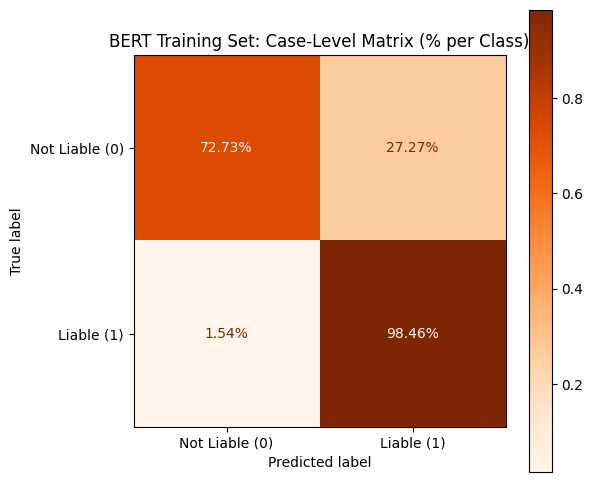

In [22]:
# Extract the true labels and the case-level predictions for the TRAINING set
y_true_case_train = bert_case_eval_train['target']
y_pred_case_train = bert_case_eval_train['case_pred']

# 1. Calculate Normalized Matrix (Percentages)
cm_case_percent_train = confusion_matrix(y_true_case_train, y_pred_case_train, normalize='true')

# 2. Plot with Percentages
fig, ax = plt.subplots(figsize=(6, 6))
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_case_percent_train,
    display_labels=["Not Liable (0)", "Liable (1)"]
)

# Use '.2%' format to show percentages
disp_train.plot(cmap=plt.cm.Oranges, values_format='.2%', ax=ax)

plt.title("BERT Training Set: Case-Level Matrix (% per Class)")
plt.show()

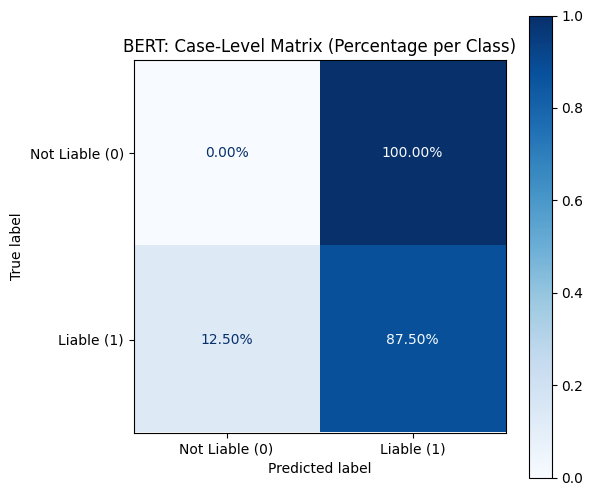

In [23]:
# Extract the true labels and the case-level predictions for the BERT model.
y_true_case = bert_case_eval['target']
y_pred_case = bert_case_eval['case_pred'] # Use 'case_pred' from bert_case_eval

# 1. Calculate Normalized Matrix (Percentages)
cm_case_percent = confusion_matrix(y_true_case, y_pred_case, normalize='true')

# 2. Plot with Percentages
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_case_percent,
    display_labels=["Not Liable (0)", "Liable (1)"]
)
# Use '.2%' format to show percentages
disp.plot(cmap=plt.cm.Blues, values_format='.2%', ax=ax)

plt.title("BERT: Case-Level Matrix (Percentage per Class)")
plt.show()

## BERT: Non-Linear Head Classifier
Standard sequence classification models attach a simple, single linear layer to the top of the BERT architecture. Because legal reasoning often relies on complex, conditional logic rather than simple linear combinations of features, we implement a custom PyTorch `nn.Module`.

This architecture separates the model into two components:
1. **The Feature Extractor:** A frozen or trainable base `Legal-BERT` that outputs a 768-dimensional contextual embedding (`[CLS]` token).
2. **The Non-Linear Head:** A custom Multi-Layer Perceptron (MLP) utilizing `Dropout` for heavy regularization, dimensionality reduction (768 -> 256), `LayerNorm` for gradient stability, and a `GELU` activation function. The `GELU` non-linearity is crucial, as it empowers the network to learn complex, non-linear boundaries between the "Liable" and "Not Liable" classes.

Finally, the forward pass packages the output using `SequenceClassifierOutput`, allowing this custom PyTorch class to seamlessly integrate with the standard Hugging Face `Trainer` API.

In [25]:
class LegalBertNonLinear(nn.Module):
    def __init__(self, model_name="nlpaueb/legal-bert-base-uncased", num_labels=2):
        super(LegalBertNonLinear, self).__init__()
        self.num_labels = num_labels

        # 1. Load the base model (This gets the raw embeddings, no classification head)
        self.bert = AutoModel.from_pretrained(model_name)

        # 2. Build the Custom Non-Linear Classification Head
        # BERT's standard output size is 768
        hidden_size = self.bert.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )


    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None, **kwargs):

        # Pass token_type_ids into the base BERT model
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        # Extract the [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]

        # Pass the [CLS] token through your custom non-linear head
        logits = self.classifier(cls_output)

        # Calculate the loss
        loss = None
        if labels is not None:
            loss_function = nn.CrossEntropyLoss()
            loss = loss_function(logits.view(-1, self.num_labels), labels.view(-1))

        # Return standard HF output
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

In [26]:
# 1. Initialize your custom non-linear model
print("Loading Legal BERT with Custom Non-Linear Head...")
model = LegalBertNonLinear(num_labels=2)

# Ensure the model is sent to the GPU if Colab has one available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,              # 5 passes through the data is usually plenty for BERT
    per_device_train_batch_size=8,   # Keep small (8 or 16) to avoid crashing Colab's RAM
    per_device_eval_batch_size=8,
    warmup_ratio = 0.1,                # Slowly ramps up learning rate to avoid destabilizing the model
    weight_decay=0.05,                # Regularization to prevent overfitting
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",           # Evaluate validation set at the end of each epoch
    save_strategy="epoch",           # Save model checkpoint at the end of each epoch
    load_best_model_at_end=True,     # At the end, load the weights that performed best on Val
    metric_for_best_model="roc_auc",      # Determine "best" by F1 score, not just accuracy
    greater_is_better=True,
    learning_rate=2e-5
)

# 2. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# 3. TEST BEFORE TRAINING (Baseline Evaluation)
print("\n--- Evaluating Baseline (Before Fine-Tuning) ---")
baseline_results = trainer.evaluate()
print("Baseline Results:", baseline_results)

# 4. START TRAINING!
print("\n--- Starting Fine-Tuning ---")
trainer.train()

Loading Legal BERT with Custom Non-Linear Head...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5


--- Evaluating Baseline (Before Fine-Tuning) ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Baseline Results: {'eval_loss': 0.7982270121574402, 'eval_model_preparation_time': 0.0083, 'eval_accuracy': 0.40625, 'eval_f1': 0.0, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_roc_auc': 0.6072874493927125, 'eval_runtime': 1.0872, 'eval_samples_per_second': 29.433, 'eval_steps_per_second': 3.679}

--- Starting Fine-Tuning ---


/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy,F1,Precision,Recall,Roc Auc
1,0.705857,0.712967,0.008300,0.593750,0.734694,0.600000,0.947368,0.412955
2,0.676607,0.760055,0.008300,0.437500,0.500000,0.529412,0.473684,0.433198
3,0.403673,0.949638,0.008300,0.375000,0.500000,0.476190,0.526316,0.307692
4,0.284006,1.245107,0.008300,0.562500,0.708333,0.586207,0.894737,0.315789
5,0.234615,1.195514,0.008300,0.500000,0.636364,0.560000,0.736842,0.279352


/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct fro

TrainOutput(global_step=160, training_loss=0.49437607228755953, metrics={'train_runtime': 251.0871, 'train_samples_per_second': 5.058, 'train_steps_per_second': 0.637, 'total_flos': 0.0, 'train_loss': 0.49437607228755953, 'epoch': 5.0})

In [27]:
print("\n--- Final Training Set Evaluation ---")
train_results = trainer.evaluate(train_dataset)

print(f"Train Accuracy:  {train_results['eval_accuracy']:.4f}")
print(f"Train F1-Score:  {train_results['eval_f1']:.4f}")
print(f"Train Precision: {train_results['eval_precision']:.4f}")
print(f"Train Recall:    {train_results['eval_recall']:.4f}")
print(f"Train ROC AUC:   {train_results['eval_roc_auc']:.4f}")


--- Final Training Set Evaluation ---


/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Train Accuracy:  0.8740
Train F1-Score:  0.8621
Train Precision: 0.9259
Train Recall:    0.8065
Train ROC AUC:   0.9411


In [28]:
print("\n--- Final Test Set Evaluation ---")
test_results = trainer.evaluate(test_dataset)

print(f"Test Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"Test F1-Score:  {test_results['eval_f1']:.4f}")
print(f"Test Precision: {test_results['eval_precision']:.4f}")
print(f"Test Recall:    {test_results['eval_recall']:.4f}")
print(f"Test ROC AUC:    {test_results['eval_roc_auc']:.4f}")


--- Final Test Set Evaluation ---


/tmp/ipykernel_3752/406032217.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Test Accuracy:  0.3889
Test F1-Score:  0.4634
Test Precision: 0.5588
Test Recall:    0.3958
Test ROC AUC:    0.3802


**Case-level Evaluation** (Same as above)



In [29]:
# 1. Modify function to return the "Probability of Liability"
def get_bert_probability(text):
    text = str(text) if pd.notnull(text) else ""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        # Convert logits to 0-1 probabilities using Softmax
        probs = torch.softmax(logits, dim=1)

    return probs[0][1].item() # Return probability of Class 1 (Liable)

In [30]:
print("------TRAINING SET EVALUATION ------")
# 2. Apply to get raw scores for the TRAINING set
train_df['bert_prob'] = train_df['bert_text'].apply(get_bert_probability)

# 3. Aggregate by Mean Probability
bert_case_eval_train = train_df.groupby('Case_Number').agg({
    'target': 'first',
    'bert_prob': 'mean' # Average the confidence across all facts
}).reset_index()

# 4. Final Decision based on 0.5 threshold
bert_case_eval_train['case_pred'] = (bert_case_eval_train['bert_prob'] >= 0.5).astype(int)

# 5. Print the Final Report
print("--- CASE-LEVEL CLASSIFICATION REPORT (Majority Vote via Mean) ---")
print(classification_report(
    bert_case_eval_train['target'],
    bert_case_eval_train['case_pred'],
    target_names=["Not Liable (0)", "Liable (1)"]
))

------TRAINING SET EVALUATION ------
--- CASE-LEVEL CLASSIFICATION REPORT (Majority Vote via Mean) ---
                precision    recall  f1-score   support

Not Liable (0)       0.73      0.86      0.79        44
    Liable (1)       0.89      0.78      0.84        65

      accuracy                           0.82       109
     macro avg       0.81      0.82      0.81       109
  weighted avg       0.83      0.82      0.82       109



In [34]:
print("------TESTING SET EVALUATION ------")
# 2. Apply to get raw scores
test_df['bert_prob'] = test_df['bert_text'].apply(get_bert_probability)

# 3. Aggregate by Mean Probability
bert_case_eval = test_df.groupby('Case_Number').agg({
    'target': 'first',
    'bert_prob': 'mean'
}).reset_index()

# 4. Final Decision based on 0.5 threshold
bert_case_eval['case_pred'] = (bert_case_eval['bert_prob'] >= 0.50).astype(int)

print(classification_report(bert_case_eval['target'], bert_case_eval['case_pred']))

------TESTING SET EVALUATION ------
              precision    recall  f1-score   support

           0       0.30      0.38      0.33         8
           1       0.64      0.56      0.60        16

    accuracy                           0.50        24
   macro avg       0.47      0.47      0.47        24
weighted avg       0.53      0.50      0.51        24



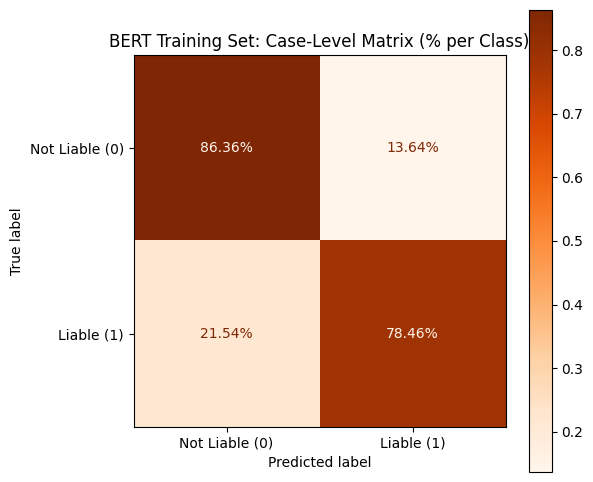

In [32]:
# Extract the true labels and the case-level predictions for the TRAINING set
y_true_case_train = bert_case_eval_train['target']
y_pred_case_train = bert_case_eval_train['case_pred']

# 1. Calculate Normalized Matrix (Percentages)
cm_case_percent_train = confusion_matrix(y_true_case_train, y_pred_case_train, normalize='true')

# 2. Plot with Percentages
fig, ax = plt.subplots(figsize=(6, 6))
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_case_percent_train,
    display_labels=["Not Liable (0)", "Liable (1)"]
)

# Use '.2%' format to show percentages
disp_train.plot(cmap=plt.cm.Oranges, values_format='.2%', ax=ax)

plt.title("BERT Training Set: Case-Level Matrix (% per Class)")
plt.show()

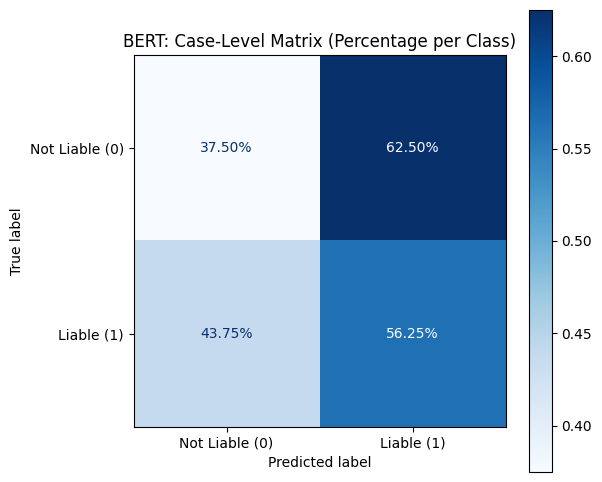

In [33]:
# the true labels and the case-level predictions for the BERT model.

y_true_case = bert_case_eval['target']
y_pred_case = bert_case_eval['case_pred']

# 1. Calculate Normalized Matrix (Percentages)
cm_case_percent = confusion_matrix(y_true_case, y_pred_case, normalize='true')

# 2. Plot with Percentages
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_case_percent,
    display_labels=["Not Liable (0)", "Liable (1)"]
)
# Use '.2%' format to show percentages
disp.plot(cmap=plt.cm.Blues, values_format='.2%', ax=ax)

plt.title("BERT: Case-Level Matrix (Percentage per Class)")
plt.show()

# Model Evaluation: Linear vs. Non-Linear Classification Head

To evaluate the structural requirements for legal NLP, we compared a standard Hugging Face linear classification head against our custom `LegalBertNonLinear` PyTorch architecture (utilizing a multi-layer perceptron with a `GELU` activation function).

The results highlight a classic machine learning trap: relying solely on overall accuracy when dealing with imbalanced datasets.

#### 1. Row-Level Performance (Individual Defendants)

| Metric | Linear Head (Default) | Non-Linear Head (Custom) | Impact |
| :--- | :--- | :--- | :--- |
| **Accuracy** | **65.28%** | 38.89% | Dropped (Expected, see analysis) |
| **ROC-AUC** | 0.3351 | **0.3802** | Improved (Better probability ranking) |
| **F1-Score** | **0.7826** | 0.4634 | Dropped |
| **Precision** | **0.6716** | 0.5588 | Dropped |
| **Recall** | **0.9375** | 0.3958 | Dropped |

#### 2. Case-Level Performance (Overall Litigation Outcomes)

| Metric | Linear Head (Default) | Non-Linear Head (Custom) | Impact |
| :--- | :--- | :--- | :--- |
| **Case Accuracy** | **58.0%** | 50.0% | Dropped |
| **Class 0 F1 (Not Liable)** | 0.00 | **0.33** | **Critical Improvement** |
| **Class 1 F1 (Liable)** | **0.74** | 0.60 | Dropped |
| **Weighted F1-Score**| 0.49 | **0.51** | **Improved** |


### Analysis: The "Lazy" Linear Model vs. The Non-Linear Solution

At first glance, the default Linear Head appears to outperform the custom architecture across most top-line metrics. However, a deeper look at the Case-Level Classification Report reveals a fatal flaw in the linear architecture: **Majority-Class Collapse.**

**1. The Failure of the Linear Baseline:**
The linear model achieved its 65% row-level accuracy and 93% recall by acting as a "lazy" classifier. It overwhelmingly predicted the majority class ("Liable"), entirely failing to parse the nuance of a defense victory. This is proven by its Case-Level Class 0 F1-Score of **0.00**. In a real-world legal setting, a model that cannot identify a "Not Liable" outcome offers zero strategic utility to a defense team. A simple linear boundary cannot handle conditional legal logic (e.g., *if X happened, but Y is true, then Not Liable*).

**2. The Structural Success of the Non-Linear Architecture:**
By introducing hidden layers and the `GELU` activation function, we allowed the neural network to learn complex, non-linear boundaries. While overall accuracy dropped as the model stopped blindly guessing "Liable," its true predictive intelligence improved significantly:
* **The Return of Class 0:** The custom model successfully began identifying true defense victories, bringing the Class 0 F1-score up from absolute zero to **0.33**.
* **Better Probability Calibration:** The ROC-AUC improved from 0.33 to 0.38 at the row level, proving the non-linear model is better at actually sorting and ranking risk probabilities, rather than just forcing hard labels.
* **Higher Weighted F1:** Despite the drop in pure accuracy, the Case-Level Weighted F1 increased to **0.51**, indicating a more balanced, healthier model across *both* classes.

**Conclusion:** The non-linear classification heads are required to force the model to learn complex legal distinctions, rather than collapsing into majority-class memorization. The `LegalBertNonLinear` model provides the foundational structure needed to move forward.